# 02. Baseline Model - Job Salary Prediction


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
import joblib
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded!')

Libraries loaded!


In [4]:
# Load splits (EDA output)
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

print(f'Train: {train.shape}, Test: {test.shape}')
print('Target stats:')
print(train['avg_ctc'].describe())

Train: (3600, 18), Test: (901, 18)
Target stats:
count      3461.000000
mean     335544.199075
std      133965.924218
min        1440.000000
25%      230000.000000
50%      300000.000000
75%      400000.000000
max      675000.000000
Name: avg_ctc, dtype: float64


In [5]:
# Features (EDA features + categoricals)
features = ['min_exp', 'max_exp', 'posted_days']

# Top 20 jobs/locations for encoding
top_jobs = train['job_title'].value_counts().head(20).index
train['job_top'] = pd.Categorical(train['job_title'].where(train['job_title'].isin(top_jobs), 'Other'))
test['job_top'] = pd.Categorical(test['job_title'].where(test['job_title'].isin(top_jobs), 'Other'))

top_locations = train['location'].value_counts().head(20).index
train['loc_top'] = pd.Categorical(train['location'].where(train['location'].isin(top_locations), 'Other'))
test['loc_top'] = pd.Categorical(test['location'].where(train['location'].isin(top_locations), 'Other'))

# Dummies
all_features = features + ['job_top', 'loc_top']
X_train = pd.get_dummies(train[all_features], drop_first=True)
y_train = train['avg_ctc'].fillna(train['avg_ctc'].median())

X_test = pd.get_dummies(test[all_features], drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)  # Align columns
y_test = test['avg_ctc'].fillna(train['avg_ctc'].median())

print(f'Features: {X_train.shape[1]}')
print(X_train.head())

Features: 43
   min_exp  max_exp  posted_days  job_top_Business Development Associate  \
0        1        3           21                                   False   
1        0        5           14                                    True   
2        1        3            6                                   False   
3        0        2            7                                   False   
4        0        2           14                                   False   

   job_top_Business Development Executive  \
0                                   False   
1                                   False   
2                                   False   
3                                   False   
4                                   False   

   job_top_Business Development Manager  job_top_Content Writer  \
0                                 False                   False   
1                                 False                   False   
2                                 False                   

In [6]:
# XGBoost baseline
model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'✅ BASELINE MODEL COMPLETE!')
print(f'MAE: ₹{mae:,.0f}')
print(f'R² Score: {r2:.3f}')
print(f'Median baseline: ₹{y_test.median():,.0f}')

✅ BASELINE MODEL COMPLETE!
MAE: ₹65,768
R² Score: 0.568
Median baseline: ₹300,000


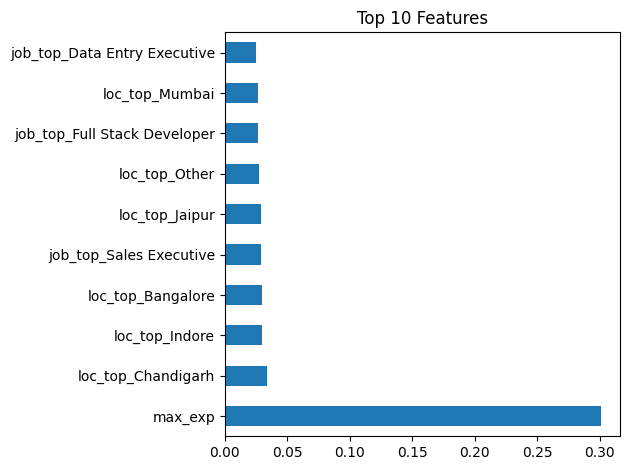

✅ Model saved! Ready for deployment.


In [9]:
# Feature importance
import matplotlib.pyplot as plt
importance = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importance.head(10).plot(kind='barh', title='Top 10 Features')
plt.tight_layout()
plt.show()

# Save model
joblib.dump(model, r'C:\Users\Manikanth Reddy\Documents\dev\Jobs\notebooks\baseline_salary_model.joblib')
print('✅ Model saved! Ready for deployment.')